## COVID Drivers: Modeling

This notebook models 
* POST_COVID
* CELL_PHONE
* IMPAIRED_DRIVER
* MATURE_DRIVER
* YOUNG_DRIVER
* FATIGUE_ASLEEP
* HIT_RUN
* UNLICENSED
* URBAN_RURALx</BR></BR>
 ~ NO_CLEARANCE

https://machinelearningmastery.com/one-class-classification-algorithms/

### Table of Contents
* [Read the Data](#read)</BR>
* [Preprocessing](#prep)</BR>
* [Review Models](#review)


Import packages

In [49]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import xgboost as xgb
from functools import reduce
#import prince

from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [2]:
# Import project specific utilities
from utils.functions import *

In [3]:
path_in = 'data/ready/ready_data.csv'

In [96]:
outcome_cols = ['AGGRESSIVE_DRIVING', # Each will be assessed as a single outcome in separate models
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING']

SYNTHETIC

Counter({np.int64(0): 9990, np.int64(1): 10})


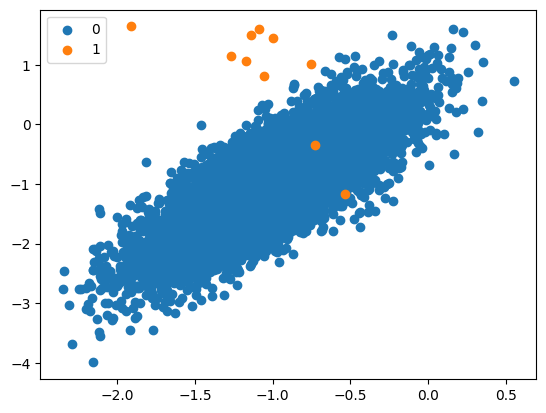

In [ ]:
from sklearn.datasets import make_classification
# define dataset
X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
	n_clusters_per_class=1, weights=[0.999], flip_y=0, random_state=4)
# summarize class distribution
counter = Counter(y)
print(counter)
# scatter plot of examples by class label
for label, _ in counter.items():
	row_ix = np.where(y == label)[0]
	plt.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
plt.legend()
plt.show()

### <a id='read'>Read the data</a>

In [55]:
df_init = pd.read_csv(path_in, low_memory=False)

In [56]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [57]:
df = df_init.set_index('CRASH_DATE').drop(columns=['CRN']).copy()

In [58]:
model_metrics = []

In [59]:
df.columns.tolist()

['POST_COVID',
 'ALCOHOL_RELATED',
 'CELL_PHONE',
 'DISTRACTED',
 'DRINKING_DRIVER',
 'DRIVER_16YR',
 'DRIVER_17YR',
 'DRIVER_18YR',
 'DRIVER_19YR',
 'DRIVER_20YR',
 'DRIVER_50_64YR',
 'DRIVER_65_74YR',
 'DRIVER_75PLUS',
 'DRUGGED_DRIVER',
 'DRUG_RELATED',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'ILLEGAL_DRUG_RELATED',
 'IMPAIRED_DRIVER',
 'IMPAIRED_NONMOTORIST',
 'MARIJUANA_DRUGGED_DRIVER',
 'MARIJUANA_RELATED',
 'MATURE_DRIVER',
 'MC_DRINKING_DRIVER',
 'OPIOID_RELATED',
 'UNDERAGE_DRNK_DRV',
 'UNLICENSED',
 'YOUNG_DRIVER',
 'AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING',
 'COUNTYx',
 'URBAN_RURALx']

# NO_CLEARANCE

### <a id='prep'>Preprocessing</a>

In [60]:
#X = df.loc[:,['POST_COVID']].to_numpy().copy()

In [73]:
X = df.loc[:,['POST_COVID',
 'CELL_PHONE',
 'IMPAIRED_DRIVER',
 'MATURE_DRIVER',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'UNLICENSED']].to_numpy().copy()

In [74]:
y = df['NO_CLEARANCE']

In [77]:
trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.5, random_state=2, stratify=y)

Counter({0: 2292712, 1: 167772})


/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


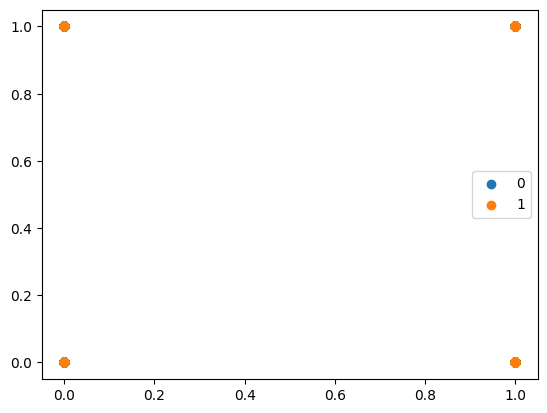

In [78]:
# Generate and plot the imbalanced classification dataset
# summarize class distribution
counter = Counter(y)
print(counter)
# scatter plot of examples by class label
for label, _ in counter.items():
	row_ix = np.where(y == label)[0]
	plt.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
plt.legend()
plt.show()


In [79]:
# define outlier detection model
model = OneClassSVM(gamma='scale', nu=0.01)

In [80]:
# fit on majority class
trainX = trainX[trainy==0]
model.fit(trainX)

In [81]:
# detect outliers in the test set
yhat = model.predict(testX)

In [82]:
# mark inliers 1, outliers -1
testy[testy == 1] = -1
testy[testy == 0] = 1

In [83]:
# calculate score
score = f1_score(testy, yhat, pos_label=-1)
print('F1 Score: %.3f' % score)

F1 Score: 0.113


# SPEEDING

### <a id='prep'>Preprocessing</a>

In [84]:
#X = df.loc[:,['POST_COVID']].to_numpy().copy()

In [85]:
X = df.loc[:,['POST_COVID',
 'CELL_PHONE',
 'IMPAIRED_DRIVER',
 'MATURE_DRIVER',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'UNLICENSED']].to_numpy().copy()

In [86]:
y = df['SPEEDING']

In [87]:
trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.5, random_state=2, stratify=y)

Counter({0: 2374161, 1: 86323})


/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


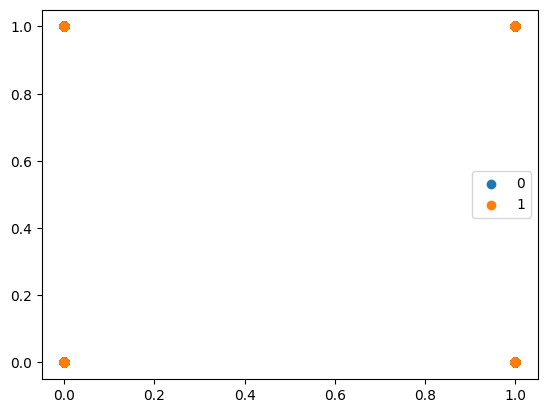

In [88]:
# Generate and plot the imbalanced classification dataset
# summarize class distribution
counter = Counter(y)
print(counter)
# scatter plot of examples by class label
for label, _ in counter.items():
	row_ix = np.where(y == label)[0]
	plt.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
plt.legend()
plt.show()


In [89]:
# define outlier detection model
model = OneClassSVM(gamma='scale', nu=0.01)

In [90]:
# fit on majority class
trainX = trainX[trainy==0]
model.fit(trainX)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.01
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [91]:
# detect outliers in the test set
yhat = model.predict(testX)

In [94]:
# mark inliers 1, outliers -1
testy[testy == 1] = -1
testy[testy == 0] = 1

In [95]:
# calculate score
score = f1_score(testy, yhat, pos_label=-1)
print('F1 Score: %.3f' % score)

F1 Score: 0.674
